In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import sys, os
# This is not super pretty, but I think this is the best way to import stuff from ../../../util?
CODE_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if CODE_ROOT not in sys.path:
    sys.path.insert(1, CODE_ROOT)

from dataset_functions import get_shuffled_and_split_datasets, get_sdss_spectra, get_spectra_reference_point
from util.spectra_helpers import SpectraCustomHDF5

## Load SDSS spectra

In [2]:
# Load
cat = np.load("../SDSS_support_files/Custom_cat.npz")
snrs_cat = cat["SNR"]
pmfs_cat = cat["PMF"]

In [3]:
pmf_list = []
snr_filter = 2
for i in range(len(snrs_cat)):
    if snrs_cat[i] > snr_filter:
        pmf_list.append(pmfs_cat[i])

print(len(pmf_list))

10132


In [4]:
resid_file = "../SDSS_support_files/residcorr_v5_4_45.dat"

# Note: this function might take a couple of minutes to run as it has to open thousands of data files
snrs, wavelengths_boss_specs, fluxes_boss_specs = get_sdss_spectra(resid_file, pmf_list)

  0%|          | 0/10132 [00:00<?, ?it/s]/vera/u/jerbo/CLIMB-Project/code/Machine_Learning/Transformer_pipeline/dataset_functions.py:214: RuntimeWarning: divide by zero encountered in divide
  F[good_pixel] = (flux[good_pixel] * dla_corr[good_pixel] / ((cont[good_pixel] * resid[good_pixel])))
 31%|███       | 3091/10132 [01:13<02:48, 41.83it/s]


KeyboardInterrupt: 

In [ ]:
np_specs = []
ivar_snrs = []
for i, spec in enumerate(fluxes_boss_specs):
    if len(spec) == 402:
        np_specs.append(np.append(spec, spec[-1]))
        ivar_snrs.append(np.append(snrs[i], snrs[i][-1]))

specs = np.array(np_specs)
snrs_pp = np.array(ivar_snrs)

print(specs.shape)
print(snrs_pp.shape)

(10132, 403)
(10132, 403)


## Load ref box spectra

In [6]:
sim_spectra5, _  = get_spectra_reference_point("L25n256_realistic_noise_v2_snr2")
sim_ref_5_means = sim_spectra5.mean(axis=1)

## Calculate flux difference

In [7]:
mean_flux_sdss = specs.mean(axis=1).mean()
print(mean_flux_sdss)

mean_flux_ref_box = sim_ref_5_means.mean()
print(mean_flux_ref_box)

flux_correction = mean_flux_sdss - mean_flux_ref_box
print(flux_correction)

0.9065568
0.8079474703208721
0.09860931478578683


## Load sim spectra

In [ ]:
basepath = "/vera/ptmp/gc/jerbo/training_data/L25n256_realistic_noise_v2_snr2/"
out_path = "/vera/ptmp/gc/jerbo/training_data/L25n256_realistic_noise_v2_snr2_mean_flux_corrected/"

spectra_files_in_basepath = os.listdir(basepath)

assert len(spectra_files_in_basepath) == 151

os.makedirs(out_path, exist_ok=True)

In [15]:
for i, filename in enumerate(spectra_files_in_basepath):
    print(f"Loading file {i+1}/{len(spectra_files_in_basepath)}: {filename}")
    metadata = SpectraCustomHDF5(os.path.join(basepath, filename)).get_header()
    wavelengths, fluxes = SpectraCustomHDF5(os.path.join(basepath, filename)).get_all_spectra()
    
    fluxes += flux_correction

    spec_out_file = SpectraCustomHDF5(os.path.join(out_path, filename))
    spec_out_file.create_file(metadata, wavelengths, fluxes)

Loading file 1/151: gp17_spectra_test.hdf5
Loading file 2/151: reference_point_spectra.hdf5
Loading file 3/151: gp49_spectra_train.hdf5
Loading file 4/151: gp19_spectra_train.hdf5
Loading file 5/151: gp0_spectra_test.hdf5
Loading file 6/151: gp28_spectra_eval.hdf5
Loading file 7/151: gp22_spectra_train.hdf5
Loading file 8/151: gp11_spectra_eval.hdf5
Loading file 9/151: gp5_spectra_eval.hdf5
Loading file 10/151: gp4_spectra_test.hdf5
Loading file 11/151: gp10_spectra_train.hdf5
Loading file 12/151: gp17_spectra_train.hdf5
Loading file 13/151: gp15_spectra_eval.hdf5
Loading file 14/151: gp30_spectra_test.hdf5
Loading file 15/151: gp13_spectra_eval.hdf5
Loading file 16/151: gp48_spectra_train.hdf5
Loading file 17/151: gp11_spectra_test.hdf5
Loading file 18/151: gp6_spectra_eval.hdf5
Loading file 19/151: gp39_spectra_train.hdf5
Loading file 20/151: gp37_spectra_train.hdf5
Loading file 21/151: gp29_spectra_train.hdf5
Loading file 22/151: gp38_spectra_test.hdf5
Loading file 23/151: gp37_spec

In [18]:
sim_spectra5_corrected, _  = get_spectra_reference_point("L25n256_realistic_noise_v2_snr2_mean_flux_corrected")
sim_ref_5_corrected_means = sim_spectra5_corrected.mean(axis=1)

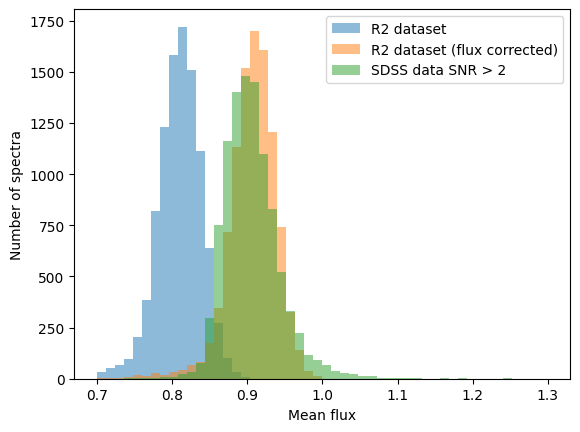

In [20]:
plt.hist(sim_ref_5_means, bins=50, alpha=0.5, label='R2 dataset', range=(0.7, 1.3))
plt.hist(sim_ref_5_corrected_means, bins=50, alpha=0.5, label='R2 dataset (flux corrected)', range=(0.7, 1.3))
plt.hist(specs.mean(axis=1), bins=50, alpha=0.5, label='SDSS data SNR > 2', range=(0.7, 1.3))
plt.legend()
plt.xlabel('Mean flux')
plt.ylabel('Number of spectra')
plt.savefig("flux_correction_histogram.pdf", format="pdf")